# Feature Análisis

In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import scipy.stats as stats
import seaborn as sns
import yfinance as yf
from scipy.stats import spearmanr
# --- Parámetros del análisis ------------------------------------------------
TICKER        = "SPY"
START         = "1993-01-01"   # inicio de la serie del ETF
END           = "2026-01-01"
TRADING_DAYS  = 252            # factor de anualización
SEED          = 42
DATA_DIR      = Path("data")

# `arch` usa el estado global de numpy: fijarlo hace reproducible el bootstrap.
np.random.seed(SEED)

# --- Estilo de figuras ------------------------------------------------------
FIGSIZE = (7.0, 3.5)
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
    "legend.frameon": False,
})

In [2]:
from pathlib import Path
from typing import List

def load_single_price(ticker = TICKER, start = START, end = END, cache_dir = DATA_DIR, refresh: bool = False) -> pd.Series:
    """Precio de cierre ajustado, con caché local en CSV para un ticker."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache = cache_dir / f"{ticker}_{start}_{end}.csv"

    if cache.exists() and not refresh:
        px = pd.read_csv(cache, index_col=0, parse_dates=True).squeeze("columns")
    else:
        raw = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
        if raw.empty:
            return pd.Series(dtype='float64', name=ticker)
        px = raw["Adj Close"].dropna().squeeze()
        px.to_csv(cache)

    # Name the series with just the ticker to ensure clean column names in the final DataFrame
    px.name = ticker 
    return px

def load_multiple_prices(tickers: List[str], start = START, end = END, cache_dir = DATA_DIR, refresh: bool = False) -> pd.DataFrame:
    """
    Descarga una lista de tickers, los persiste en CSVs individuales, 
    y retorna un DataFrame combinado.
    """
    series_list = []
    for tick in tickers:
        px_series = load_single_price(tick, start, end, cache_dir, refresh)
        if not px_series.empty:
            series_list.append(px_series)
            
    # Combine all Series into a single DataFrame aligned by date index
    if series_list:
        return pd.concat(series_list, axis=1)
    
    return pd.DataFrame()


price = load_single_price(TICKER, START, END, DATA_DIR)

# Retorno logarítmico (aditivo) y retorno simple, para comparación en la Sección 3.
log_ret    = np.log(price / price.shift(1)).dropna()
simple_ret = (price / price.shift(1) - 1.0).dropna()

print(f"Ticker          : {TICKER}")
print(f"Rango           : {price.index[0]:%Y-%m-%d} a {price.index[-1]:%Y-%m-%d}")
print(f"Observaciones   : {len(price):,} precios  |  {len(log_ret):,} retornos")
print(f"Precio inicial  : {price.iloc[0]:,.2f} USD")
print(f"Precio final    : {price.iloc[-1]:,.2f} USD")
print(f"Múltiplo total  : x{price.iloc[-1] / price.iloc[0]:,.1f}")

Ticker          : SPY
Rango           : 1993-01-29 a 2025-12-31
Observaciones   : 8,288 precios  |  8,287 retornos
Precio inicial  : 24.11 USD
Precio final    : 678.32 USD
Múltiplo total  : x28.1


# Momentum

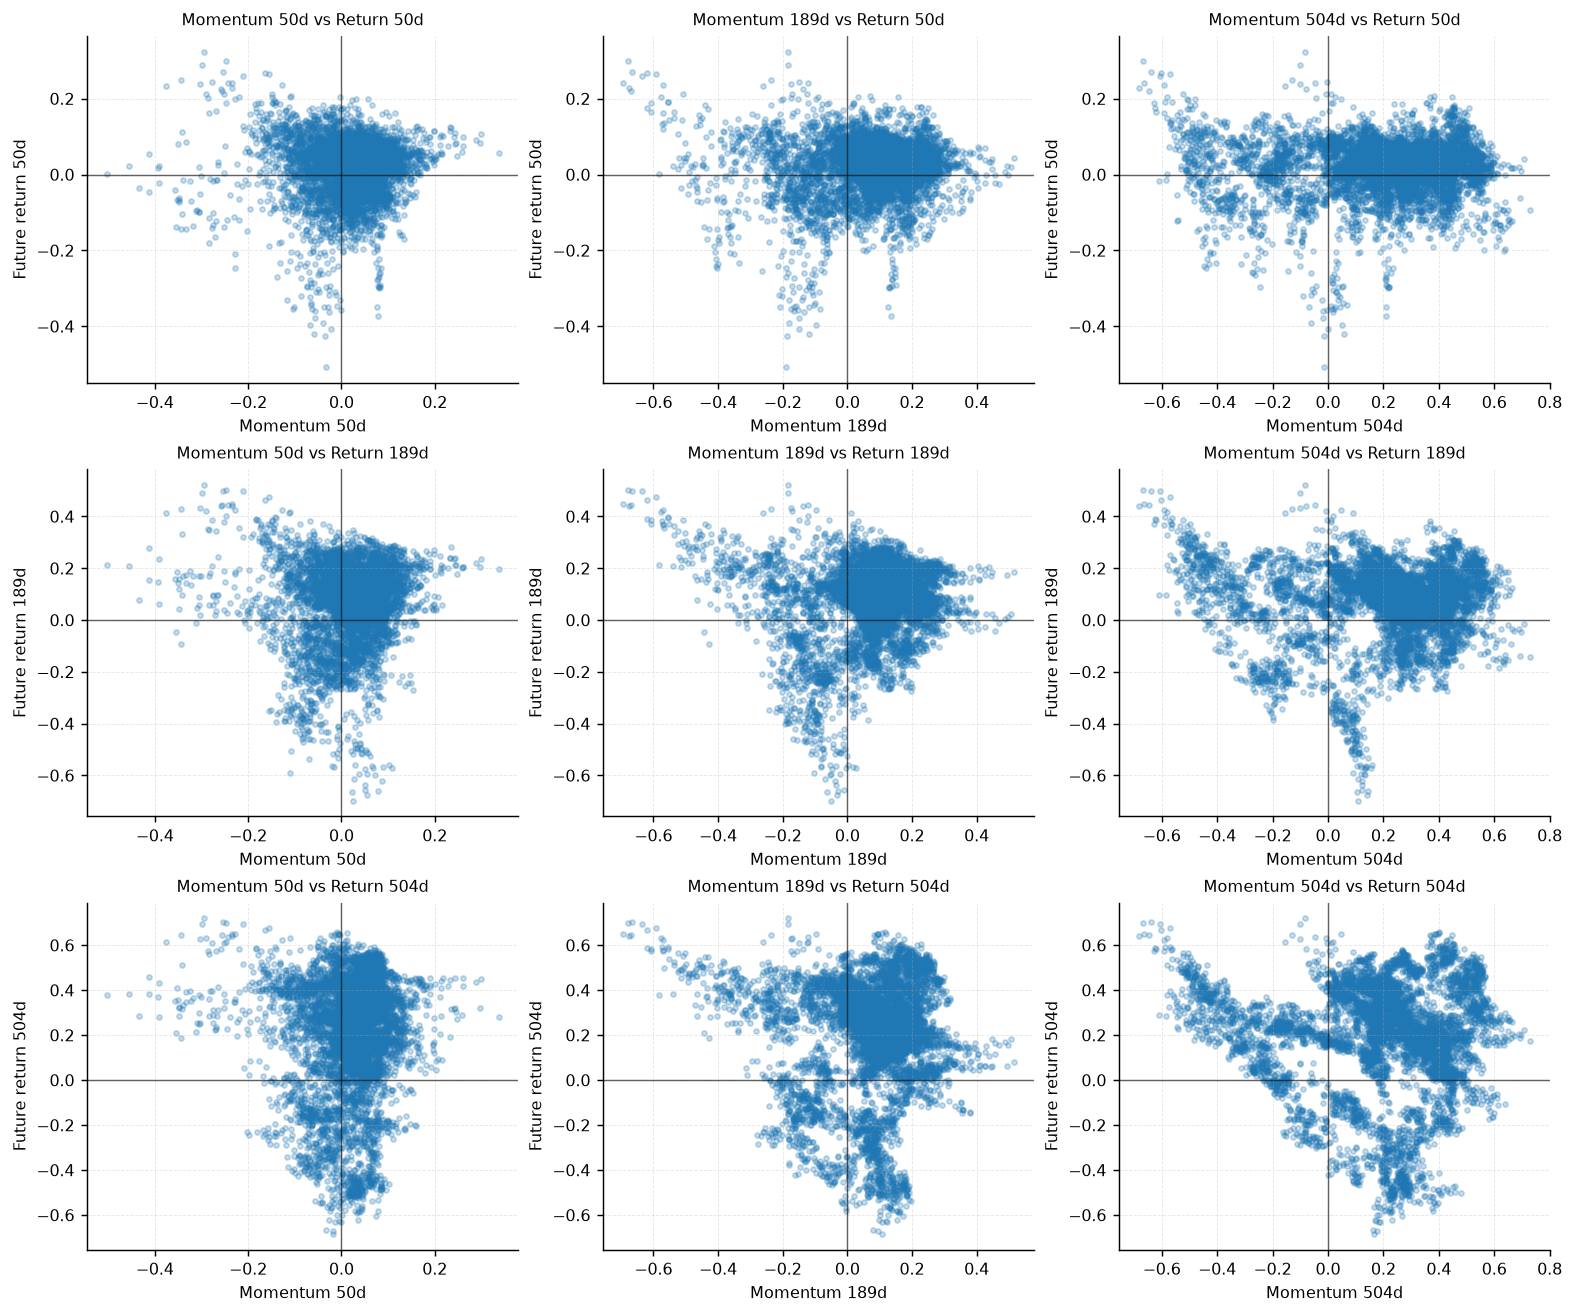

In [3]:
momentum_lags = [50, 189, 2*252]  # días de lookback para el momentum
momentum = pd.DataFrame({
    f"mom_lag{k}": (np.log(price.shift(1)) - np.log(price.shift(k + 1))).rename(f"mom_lag{k}")
    for k in momentum_lags
})
ret_to_predict_lags = [50, 189, 2*252]  # días de lookahead para el retorno a predecir
returns_to_predict = pd.DataFrame({
    f"ret_lag{k}": (np.log(price.shift(-k)) - np.log(price.shift(-1))).rename(f"ret_lag{k}")
    for k in ret_to_predict_lags
})

fig, axes = plt.subplots(
    len(ret_to_predict_lags),
    len(momentum_lags),
    figsize=(12, 10),
    sharex=False,
    sharey=False,
    constrained_layout=True,
)

for i, ret_k in enumerate(ret_to_predict_lags):
    for j, mom_k in enumerate(momentum_lags):
        ax = axes[i, j]
        data = pd.concat(
            [momentum[f"mom_lag{mom_k}"], returns_to_predict[f"ret_lag{ret_k}"]],
            axis=1
        ).dropna()

        ax.scatter(
            data.iloc[:, 0],
            data.iloc[:, 1],
            s=8,
            alpha=0.25
        )
        ax.axhline(0, color="black", lw=0.8, alpha=0.6)
        ax.axvline(0, color="black", lw=0.8, alpha=0.6)

        ax.set_title(f"Momentum {mom_k}d vs Return {ret_k}d", fontsize=9)
        ax.set_xlabel(f"Momentum {mom_k}d")
        ax.set_ylabel(f"Future return {ret_k}d")

plt.show()


In [25]:
def compute_correlation_matrix(series_x, series_y, max_lookback=504, max_lookahead=504, steps=150):
    """
    Computes a Spearman rank correlation matrix across different lookback and lookahead windows.
    
    Parameters:
    series_x : pd.Series
        The base feature series (e.g., squared log returns, log returns).
    series_y : pd.Series
        The target base series (e.g., log returns to be summed for future returns).
    max_lookback : int
        Maximum lookback window.
    max_lookahead : int
        Maximum lookahead window.
    steps : int
        Approximate number of steps to divide the total grid into.
    """
    # Calculate step size, ensuring it's at least 1
    step = max(1, (max_lookback + max_lookahead) // steps)
    
    lookbacks = np.arange(step, max_lookback + step, step)
    lookaheads = np.arange(step, max_lookahead + step, step)
    
    rank_corr_matrix = np.zeros((len(lookaheads), len(lookbacks)))
    
    # OPTIMIZATION: Precompute rolling sums for lookbacks. 
    # In the original script, `mom` was being recalculated inside the lookahead loop, 
    # which is highly inefficient since `mom` only depends on the lookback period `l`.
    mom_dict = {j: series_x.rolling(l).sum() for j, l in enumerate(lookbacks)}
    
    for i, f in enumerate(lookaheads):
        fut_ret = series_y.rolling(f).sum().shift(-f)
        
        for j in range(len(lookbacks)):
            mom = mom_dict[j]
            
            # Boolean mask to align data and drop NaNs
            valid_idx = ~(mom.isna() | fut_ret.isna())
            
            if valid_idx.sum() > 2:
                x = mom[valid_idx].values
                y = fut_ret[valid_idx].values
                corr, _ = spearmanr(x, y)
                rank_corr_matrix[i, j] = corr
            else:
                rank_corr_matrix[i, j] = np.nan
                
    return rank_corr_matrix, lookbacks, lookaheads


def plot_correlation_matrix(corr_matrix, lookbacks, lookaheads, 
                            title='Rank Correlation (Spearman) by Lag',
                            xlabel='Momentum Lookback (Days)', 
                            ylabel='Future Return Lookahead (Days)'):
    """
    Plots a heatmap of the rank correlation matrix.
    
    Parameters:
    corr_matrix : np.ndarray
        The 2D array containing correlation values.
    lookbacks : np.ndarray
        Array of lookback windows (x-axis).
    lookaheads : np.ndarray
        Array of lookahead windows (y-axis).
    title, xlabel, ylabel : str
        Plot labels, parameterized for reusability across different series pairs.
    """
    plt.figure(figsize=(10/2, 8/2), dpi = 300)
    
    ax = sns.heatmap(corr_matrix, 
                     cmap='coolwarm', 
                     center=0,
                     cbar_kws={'label': 'Spearman Rank Correlation'})

    # Dynamic tick stepping
    tick_step_x = max(1, len(lookbacks) // 10)
    ax.set_xticks(np.arange(0, len(lookbacks), tick_step_x) + 0.5)
    ax.set_xticklabels(lookbacks[::tick_step_x], rotation=45)

    tick_step_y = max(1, len(lookaheads) // 10)
    ax.set_yticks(np.arange(0, len(lookaheads), tick_step_y) + 0.5)
    ax.set_yticklabels(lookaheads[::tick_step_y], rotation=0)

    # plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    
    # Places smaller lookaheads at the bottom (standard for time-series term structures)
    plt.gca().invert_yaxis() 
    plt.tight_layout()
    plt.show()

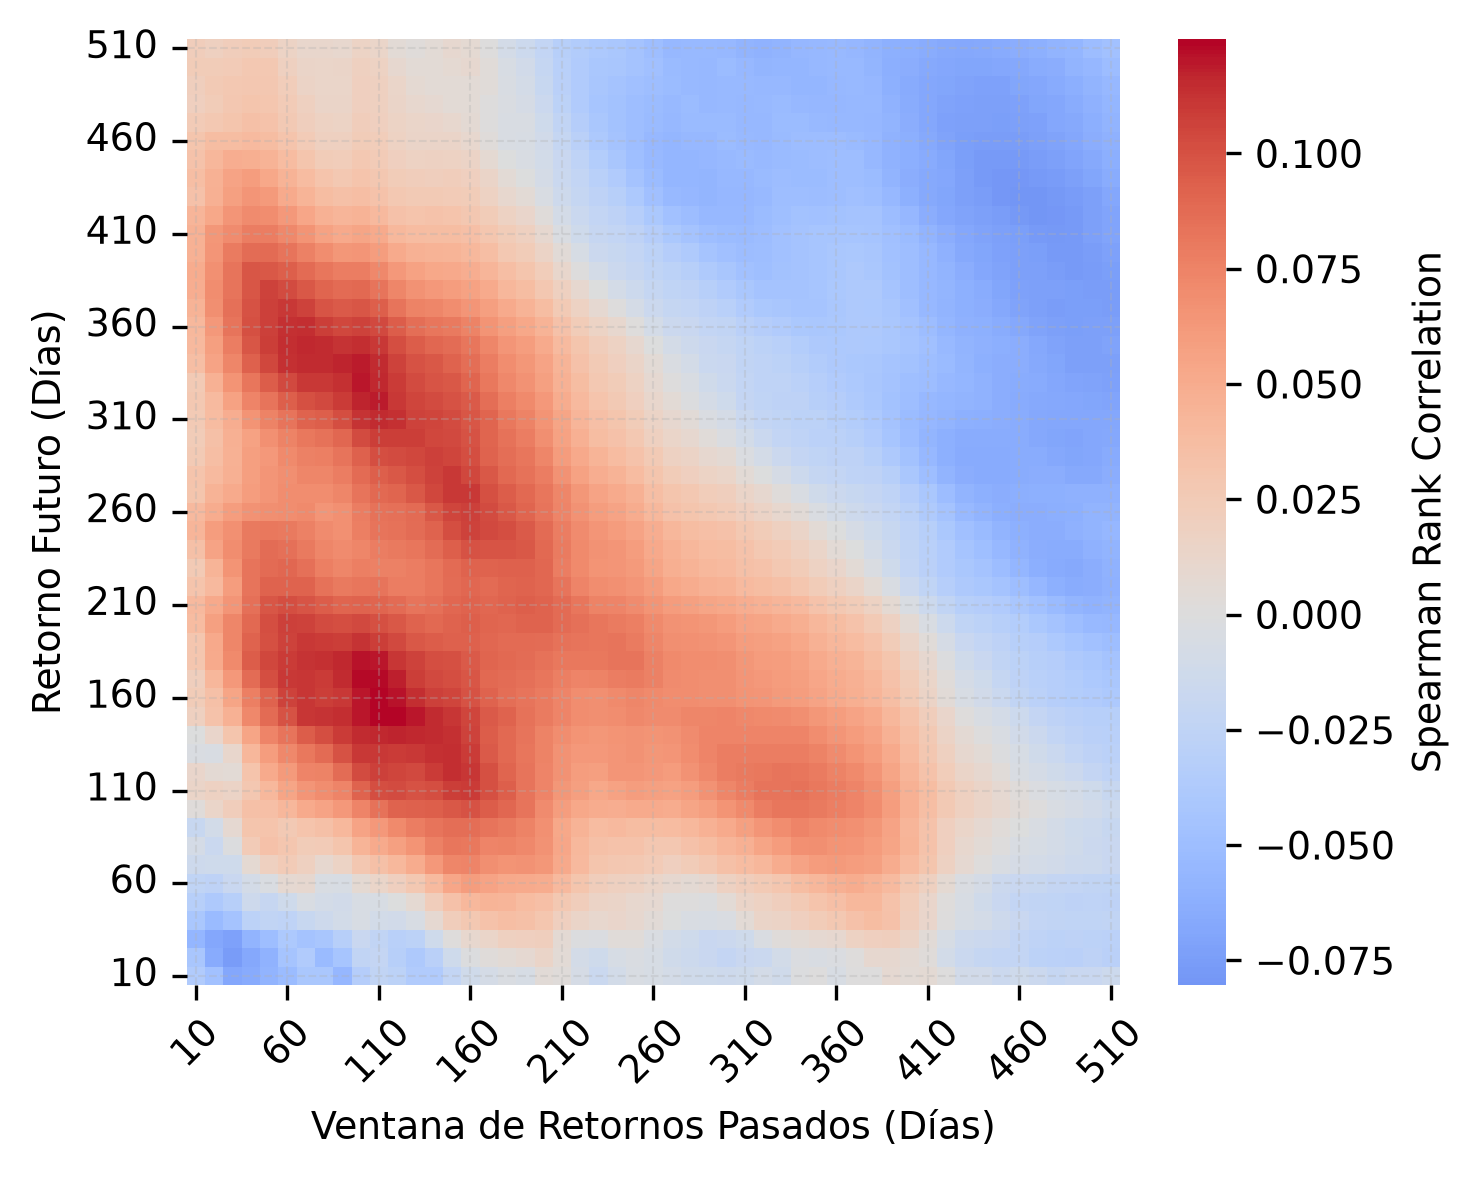

In [26]:
mom_corr_matrix, lookbacks, lookaheads = compute_correlation_matrix(log_ret, log_ret, max_lookback=504, max_lookahead=504, steps=100)
plot_correlation_matrix(mom_corr_matrix, lookbacks, lookaheads,
                        xlabel='Ventana de Retornos Pasados (Días)',
                        ylabel='Retorno Futuro (Días)')

# Volatility

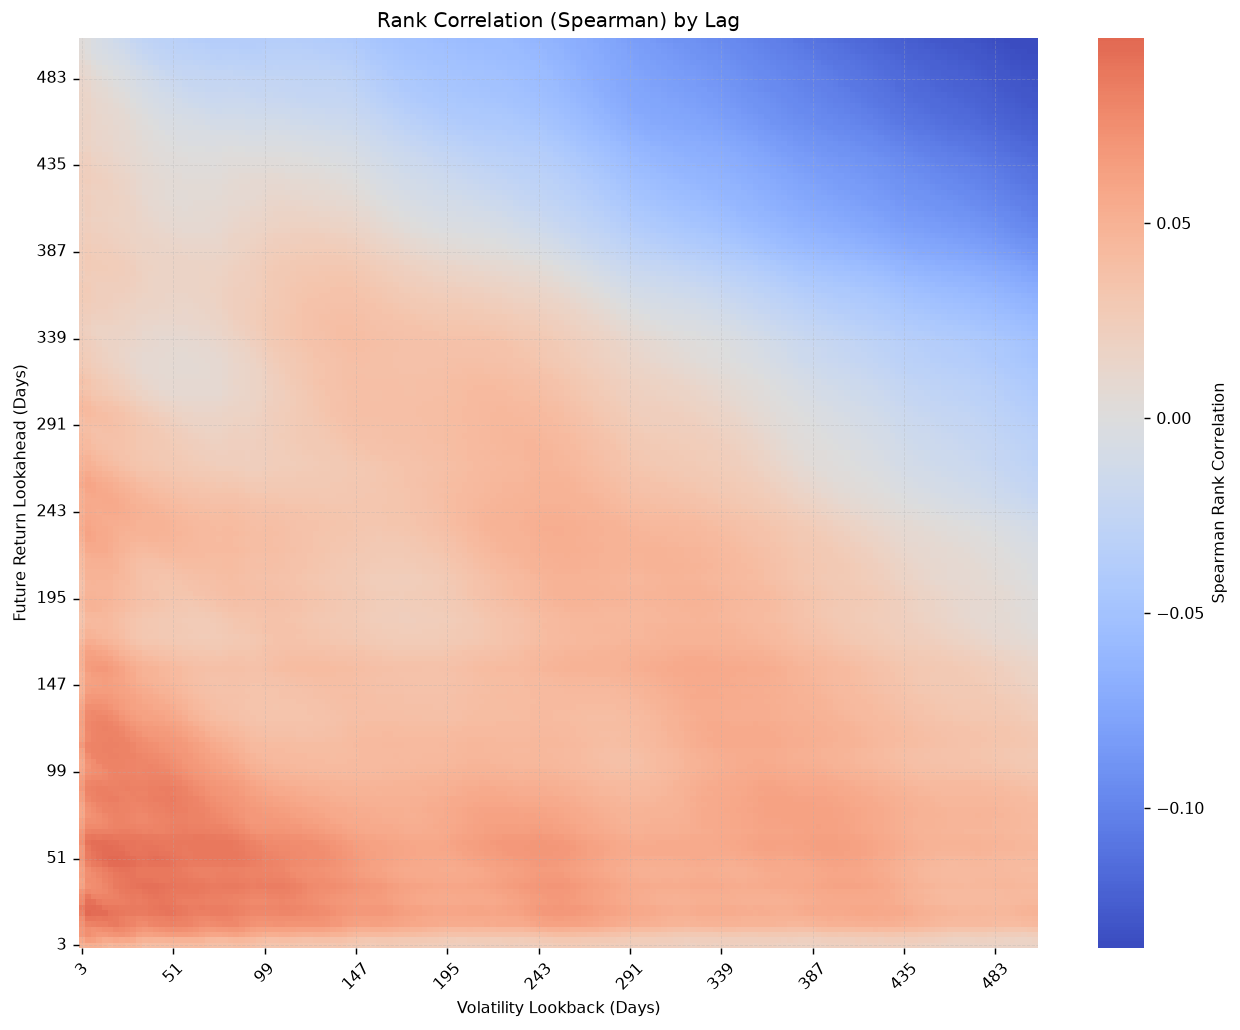

In [ ]:
mom_corr_matrix, lookbacks, lookaheads = compute_correlation_matrix(log_ret**2, log_ret, max_lookback=504, max_lookahead=504, steps=300)
plot_correlation_matrix(mom_corr_matrix, lookbacks, lookaheads,
                        xlabel='Ventana de Volatilidad Pasada (Días)',
                        ylabel='Retorno Futuro (Días)')

# Cross Sectional

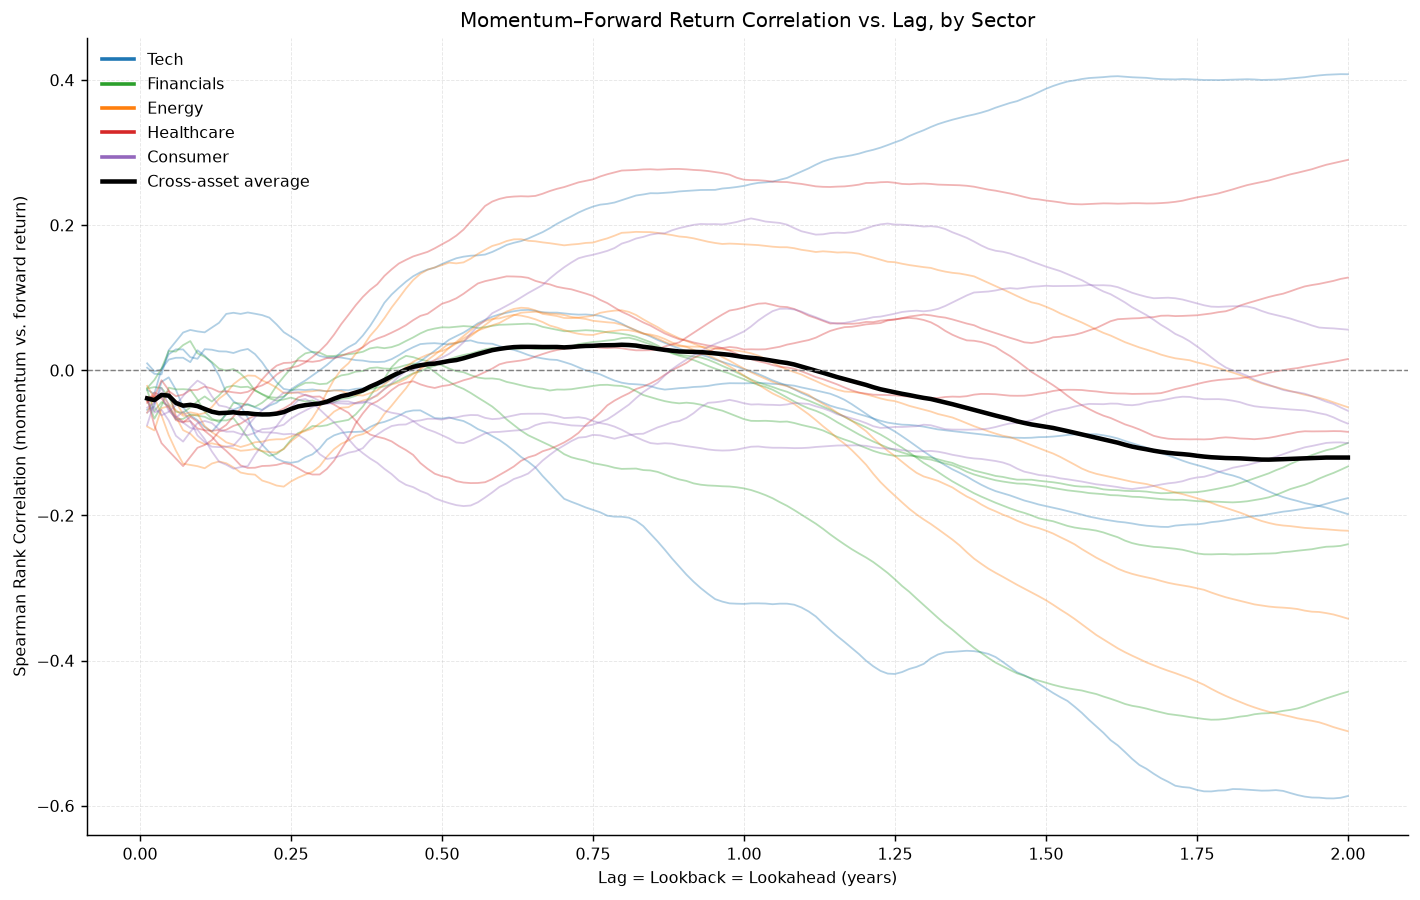

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# --- Universe: tickers grouped by sector ---
sector_tickers = {
    'Tech':  ['AAPL', 'MSFT', 'NVDA', 'GOOGL'],
    'Financials':  ['JPM', 'BAC', 'GS', 'MS'],
    'Energy':      ['XOM', 'CVX', 'SLB', 'COP'],
    'Healthcare':  ['JNJ', 'UNH', 'PFE', 'MRK'],
    'Consumer':    ['PG', 'KO', 'WMT', 'MCD'],
}
sector_colors = {
    'Tech': 'tab:blue', 'Financials': 'tab:green', 'Energy': 'tab:orange',
    'Healthcare': 'tab:red', 'Consumer': 'tab:purple',
}

trading_days_per_year = 252
max_lag = 2 * trading_days_per_year   # keep below N/3 per earlier discussion
step = max_lag // 150  # Adjust step size for better resolution
lags = np.arange(step, max_lag + step, step)
min_valid_n = 50  # discard estimates with fewer effective observations

# --- Download and compute log returns for every ticker ---
all_tickers = [t for tickers in sector_tickers.values() for t in tickers]
# raw = yf.download(all_tickers, start=start, end=end, auto_adjust=True)['Close']
raw = load_multiple_prices(all_tickers)
log_ret_df = np.log(raw / raw.shift(1)).dropna(how='all')

ticker_to_sector = {t: s for s, tickers in sector_tickers.items() for t in tickers}

# --- Correlation(lag) for each asset ---
corr_matrix = pd.DataFrame(index=lags, columns=all_tickers, dtype=float)

for ticker in all_tickers:
    log_ret = log_ret_df[ticker].dropna()
    for lag in lags:
        mom = log_ret.rolling(lag).sum()
        fut_ret = log_ret.shift(-lag).rolling(lag).sum()  # Start lookahead AFTER lookback ends
        valid_idx = ~(mom.isna() | fut_ret.isna())
        n_valid = valid_idx.sum()
        if n_valid >= min_valid_n:
            corr, _ = spearmanr(mom[valid_idx].values, fut_ret[valid_idx].values)
            corr_matrix.loc[lag, ticker] = corr

avg_corr = corr_matrix.mean(axis=1, skipna=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 7))

for ticker in all_tickers:
    sector = ticker_to_sector[ticker]
    ax.plot(lags / trading_days_per_year, corr_matrix[ticker],
             color=sector_colors[sector], alpha=0.35, linewidth=1)

ax.plot(lags / trading_days_per_year, avg_corr,
         color='black', linewidth=2.5, label='Cross-asset average')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

# Sector legend via proxy handles (avoid one entry per ticker)
from matplotlib.lines import Line2D
sector_handles = [Line2D([0], [0], color=c, lw=2, label=s) for s, c in sector_colors.items()]
sector_handles.append(Line2D([0], [0], color='black', lw=2.5, label='Cross-asset average'))
ax.legend(handles=sector_handles, loc='best')

ax.set_xlabel('Lag = Lookback = Lookahead (years)')
ax.set_ylabel('Spearman Rank Correlation (momentum vs. forward return)')
ax.set_title('Momentum–Forward Return Correlation vs. Lag, by Sector')
plt.tight_layout()
plt.show()

In [ ]:
for lag in [10, 50, 252]:
    mom = log_ret.rolling(lag).sum()
    fut_ret = log_ret.shift(-lag).rolling(lag).sum()
    valid_idx = ~(mom.isna() | fut_ret.isna())
    print(f"Lag {lag}: n_valid = {valid_idx.sum()}, "
          f"mom range [{mom[valid_idx].min():.3f}, {mom[valid_idx].max():.3f}], "
          f"fut_ret range [{fut_ret[valid_idx].min():.3f}, {fut_ret[valid_idx].max():.3f}]")

Lag 10: n_valid = 8287, mom range [-0.411, 0.256], fut_ret range [-0.411, 0.256]
Lag 50: n_valid = 8207, mom range [-0.453, 0.455], fut_ret range [-0.453, 0.455]
Lag 252: n_valid = 7803, mom range [-0.815, 0.877], fut_ret range [-0.815, 0.877]
